# Bài toán phân cụm

## Import Library(Nhập thư viện cần thiết)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



### Data Reading(Đọc dữ liệu)



Cách 1: Đọc dữ liệu từ File hướng dẫn

In [ ]:
data_train = pd.read_csv('../data/train.csv')
data_test  = pd.read_csv('../data/test.csv')
df = pd.concat([data_train, data_test])
df.head()

,Index,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


Cách 2: Đọc dữ  liệu liên kết với Google Drive chạy trên Google Colab

Link hướng dẫn như sau: https://docs.google.com/document/d/1np_fEPl3hObH9CoEBH3eS3gmeICf7rDljQ913EOFO70/edit?usp=sharing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
data_train = pd.read_csv('/content/drive/My Drive/Data/train.csv')
data_test = pd.read_csv('/content/drive/My Drive/Data/test.csv')
df = pd.concat([data_train, data_test])
df.head()

### Data Preprocessing(Tiền xử lí dữ liệu)

Bỏ 2 cột đầu tiên vì nó không được sử dụng trong thuật toán phân cụm

In [ ]:
df.drop(['Index','id'],axis = 1, inplace=True)

Dữ liệu có 129880 hàng dữ liệu và 23 cột thuộc tính

In [ ]:
df.shape

(129880, 23)

Biến Arrival Delay In Minutes có 393 hàng trống

In [ ]:
df.isnull().sum()

,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0


Loại bỏ 393 hàng có cột Arrival Delay in Minutes thì được dữ liệu không còn hàng trống nào cả

In [ ]:
df = df.dropna(subset=['Arrival Delay in Minutes'])
df.isnull().sum()

,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0


## Feature Engineering(Kỹ thuật đặc trưng)

Có 4 biến là biến số trong dữ liệu

In [ ]:
numerical_vars = ['Age','Flight Distance','Departure Delay in Minutes','Arrival Delay in Minutes']

Đây là ma trận tương quan của 4 biến số có trong dữ liệu

<Axes: >

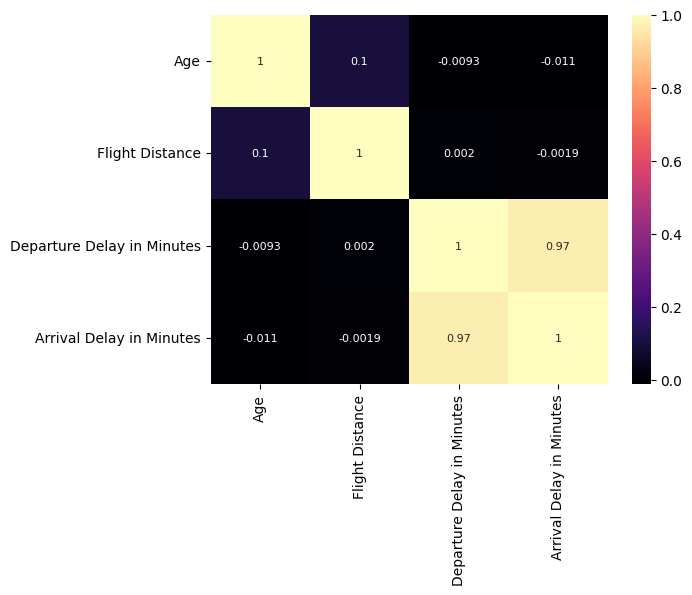

In [ ]:
sns.heatmap(
    df[numerical_vars].corr(),
    annot=True,
    cmap='magma',
    annot_kws={"size": 8}
)

Vì 2 biến Departure Delay in Minutes và Arrival Delay in Minutes có mối quan hệ tương quan cao nên ta chỉ giữ lại biến Departure Delay in Minutes tránh hiên hiện tượng đa cộng tuyến

In [ ]:
df.drop(['Arrival Delay in Minutes'],axis = 1, inplace=True)

In [ ]:
df.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'satisfaction'],
      dtype='object')

Tiền xử lí các  cột biến số còn lại bằng MinMaxScaler để đưa chuẩn hóa cùng một thang đo [0,1]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
numeric_cols = df.select_dtypes(include='number').columns

scaler = MinMaxScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,satisfaction
0,Male,Loyal Customer,0.076923,Personal Travel,Eco Plus,0.086632,0.6,0.8,0.6,0.2,...,1.0,1.0,0.8,0.6,0.75,0.8,1.0,1.0,0.015704,neutral or dissatisfied
1,Male,disloyal Customer,0.230769,Business travel,Business,0.041195,0.6,0.4,0.6,0.6,...,0.2,0.2,0.2,1.0,0.50,0.2,0.8,0.2,0.000628,neutral or dissatisfied
2,Female,Loyal Customer,0.243590,Business travel,Business,0.224354,0.4,0.4,0.4,0.4,...,1.0,1.0,0.8,0.6,0.75,0.8,0.8,1.0,0.000000,satisfied
3,Female,Loyal Customer,0.230769,Business travel,Business,0.107229,0.4,1.0,1.0,1.0,...,0.4,0.4,0.4,1.0,0.50,0.2,0.8,0.4,0.006910,neutral or dissatisfied
4,Male,Loyal Customer,0.692308,Business travel,Business,0.036955,0.6,0.6,0.6,0.6,...,1.0,0.6,0.6,0.8,0.75,0.6,0.6,0.6,0.000000,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,Male,disloyal Customer,0.346154,Business travel,Business,0.099960,0.6,0.6,0.6,0.2,...,0.8,0.8,0.6,0.4,0.75,0.8,1.0,0.8,0.000000,neutral or dissatisfied
25972,Male,Loyal Customer,0.205128,Business travel,Business,0.124192,0.8,0.8,0.8,0.8,...,0.8,0.8,0.8,1.0,1.00,1.0,1.0,0.8,0.000000,satisfied
25973,Female,Loyal Customer,0.128205,Personal Travel,Eco,0.160945,0.4,1.0,0.2,1.0,...,0.4,0.4,0.8,0.6,0.75,1.0,0.8,0.4,0.000000,neutral or dissatisfied
25974,Male,Loyal Customer,0.089744,Business travel,Business,0.221325,0.6,0.6,0.6,0.6,...,0.8,0.8,0.6,0.4,1.00,0.8,1.0,0.8,0.000000,satisfied


Vì biến Class theo thứ tự vì Eco < Eco Plus < Bussiness nên ta có thể sử dụng mã hóa nhãn bằng Label Encoding

Và biến Satisfaction cũng theo thứ tự vì neutral or dissatisfied < satisfied nên ta có thể sử dụng Label EnCoding

Còn các biến còn lại vì không theo thứ tự nên sử dụng One-hot Encoding

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# Chọn các cột số
numeric_cols = df.select_dtypes(include='number').columns

# Khởi tạo MinMaxScaler và chuẩn hóa dữ liệu
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Mã hóa cột 'satisfaction'
label_encoder = LabelEncoder()
df['satisfaction'] = label_encoder.fit_transform(df['satisfaction'])

# Mã hóa cột 'Class'
class_mapping = {
    "Eco": 0,
    "Eco Plus": 1,
    "Business": 2
}
df['Class'] = df['Class'].map(class_mapping)

# Mã hóa các cột chuỗi bằng OneHotEncoder
string_columns = df.select_dtypes(include=['object']).columns
encoded_df = pd.DataFrame()

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Áp dụng OneHotEncoder cho các cột chuỗi
for col in string_columns:
    encoded = encoder.fit_transform(df[[col]])
    cols = encoder.get_feature_names_out([col])
    encoded_part = pd.DataFrame(encoded, columns=cols, index=df.index)
    encoded_df = pd.concat([encoded_df, encoded_part], axis=1)

# Xóa các cột chuỗi gốc và nối với các cột đã mã hóa
df = df.drop(columns=string_columns)
df = pd.concat([df, encoded_df], axis=1)

df.head(10)


,Age,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Inflight service,Cleanliness,Departure Delay in Minutes,satisfaction,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel
0,0.076923,1,0.086632,0.6,0.8,0.6,0.2,1.0,0.6,1.0,...,1.0,1.0,0.015704,0,0.0,1.0,1.0,0.0,0.0,1.0
1,0.230769,2,0.041195,0.6,0.4,0.6,0.6,0.2,0.6,0.2,...,0.8,0.2,0.000628,0,0.0,1.0,0.0,1.0,1.0,0.0
2,0.243590,2,0.224354,0.4,0.4,0.4,0.4,1.0,1.0,1.0,...,0.8,1.0,0.000000,1,1.0,0.0,1.0,0.0,1.0,0.0
3,0.230769,2,0.107229,0.4,1.0,1.0,1.0,0.4,0.4,0.4,...,0.8,0.4,0.006910,0,1.0,0.0,1.0,0.0,1.0,0.0
4,0.692308,2,0.036955,0.6,0.6,0.6,0.6,0.8,1.0,1.0,...,0.6,0.6,0.000000,1,0.0,1.0,1.0,0.0,1.0,0.0
5,0.243590,0,0.232027,0.6,0.8,0.4,0.2,0.2,0.4,0.2,...,0.8,0.2,0.000000,0,1.0,0.0,1.0,0.0,0.0,1.0
6,0.512821,0,0.251414,0.4,0.8,0.4,0.6,0.4,0.4,0.4,...,1.0,0.4,0.005653,0,0.0,1.0,1.0,0.0,0.0,1.0
7,0.576923,2,0.404685,0.8,0.6,0.8,0.8,1.0,1.0,1.0,...,1.0,0.8,0.002513,1,1.0,0.0,1.0,0.0,1.0,0.0
8,0.435897,2,0.165994,0.2,0.4,0.4,0.4,0.8,0.6,0.6,...,0.2,0.4,0.000000,0,1.0,0.0,1.0,0.0,1.0,0.0
9,0.166667,0,0.207997,0.6,0.6,0.6,0.8,0.4,0.6,0.6,...,0.6,0.4,0.000000,0,0.0,1.0,0.0,1.0,1.0,0.0


Vì đây là thuật toán phân cụm do không biết được nhãn đầu ra thì ta có thể bỏ cột satisfaction để trở thành thuật toán phân cụm không nhãn

In [ ]:
Z = df
Y = df['satisfaction']
X = df.drop(columns=['satisfaction'], errors='ignore')

In [ ]:
print(X.shape)
print(Y.shape)
print(Z.shape)

(129487, 24)
(129487,)
(129487, 25)


Trực quan dữ liệu sua khi chuẩn hóa bằng hình ảnh 2D

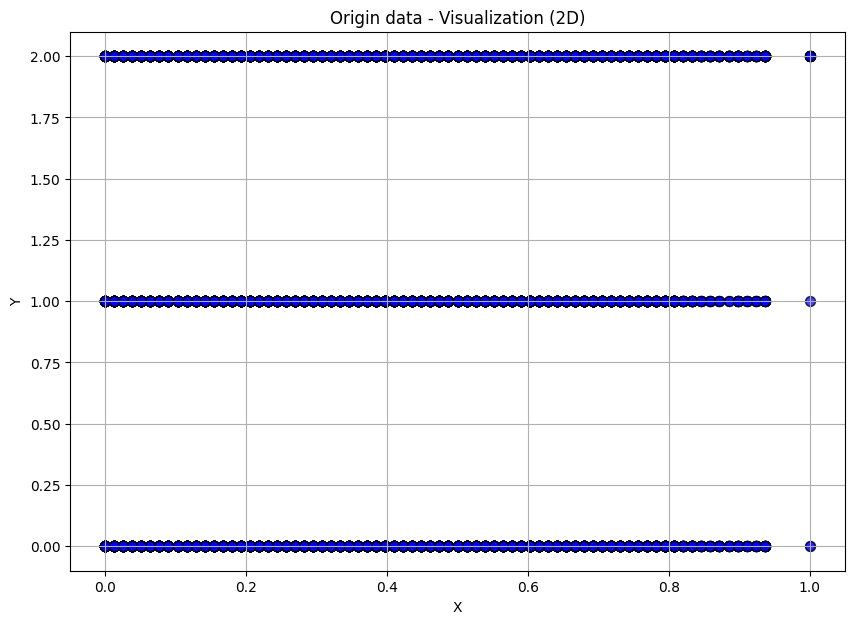

In [ ]:
# Visualize data with 2 principal components
plt.figure(figsize=(10, 7))
# Convert DataFrame X to a NumPy array before slicing
plt.scatter(X.values[:, 0], X.values[:, 1], c='blue', edgecolor='k', s=50, alpha=0.5)
plt.title("Origin data - Visualization (2D)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.savefig('Clutering_2D.png')
plt.show()

Trực quan dữ liệu bằng hình ảnh 3D

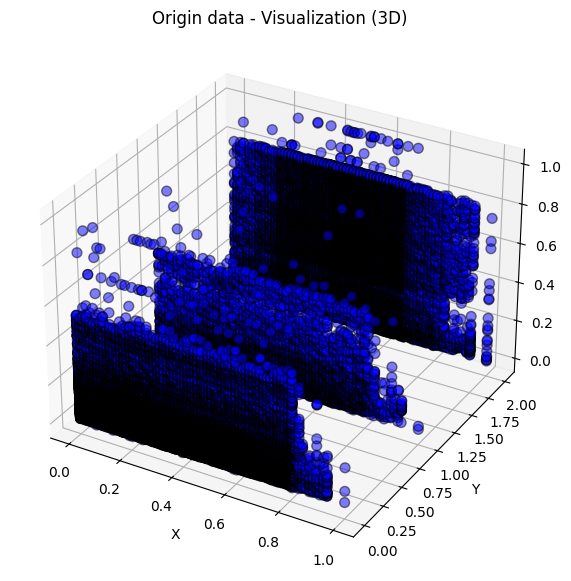

In [ ]:
# Visualize data with 3 principal components
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
# Convert DataFrame X to a NumPy array before slicing
ax.scatter(X.values[:, 0], X.values[:, 1], X.values[:, 2], c='blue', edgecolor='k', s=50, alpha=0.5)
ax.set_title("Origin data - Visualization (3D)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.grid(True)
plt.savefig('Clutering_3D.png')
plt.show()

# Thuật toán phân cụm với dữ liệu được giảm chiều bằng PCA

In [ ]:
from sklearn.decomposition import PCA

Đoạn mã `run_pca_analysis` giảm chiều bộ dữ liệu bằng PCA (tối đa 21 thành phần), xác định số thành phần tối thiểu giữ lại ≥ 90 % phương sai, rồi trực quan hoá:

 (i) đường tích lũy phương sai để chọn ngưỡng,

 (ii) scatter PC1–PC2 tô màu theo nhãn `satisfaction` để xem mức tách cụm,

 (iii) biểu đồ cột tỷ lệ phương sai từng thành phần và

 (iv) heatmap tương quan giữa `n` PC đầu và nhãn.

 Cuối cùng, hàm trả về một DataFrame gồm `n` thành phần chính cùng cột nhãn cho các bước phân tích hoặc mô hình hoá tiếp theo.


In [ ]:
def run_pca_analysis(X, y, name='default', n = 13):
    n_components = 21
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = explained_variance.cumsum()
    threshold_dim = (cumulative_variance >= 0.9).argmax() + 1

    # Biểu đồ phương sai tích lũy
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_components + 1), cumulative_variance, marker='o', linestyle='-', color='teal')
    plt.xticks(range(1, n_components + 1))
    plt.xlabel('Số chiều (số thành phần chính)')
    plt.ylabel('Tỷ lệ phương sai tích lũy')
    plt.title(f'{name} - Bảo tồn dữ liệu theo số chiều (PCA)')
    plt.axhline(y=0.9, color='red', linestyle='--', label='Ngưỡng 90%')
    plt.axvline(x=threshold_dim, color='blue', linestyle='--', label=f'{threshold_dim} chiều')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Trực quan PC1 và PC2
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'{name} - Trực quan PC1 và PC2')
    plt.colorbar(sc, label='satisfaction')
    plt.show()

    # Tỷ lệ giải thích
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=[f'PC{i+1}' for i in range(len(explained_variance))],
        y=explained_variance,
        color='skyblue'
    )
    plt.title(f'{name} - Tỷ lệ phương sai giải thích của các thành phần chính')
    plt.xlabel('Thành phần chính (Principal Component)')
    plt.ylabel('Tỷ lệ phương sai giải thích')
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Lấy dữ liệu PCA với n chiều đầu
    df_pca = pd.DataFrame(X_pca[:, :n], columns=[f'PC{i+1}' for i in range(n)])
    df_pca['satisfaction_satisfied'] = y.values

    # Heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        df_pca.corr(),
        annot=True,
        fmt=".3f",
        cmap='magma',
        annot_kws={'size': 8}
    )
    plt.title(f'{name} - Ma trận tương quan giữa các PC và satisfaction')
    plt.show()

    return df_pca

Biểu đồ phương sai tích lũy chỉ ra rằng **9 thành phần chính đầu đã giữ lại hơn 90 % thông tin** (đường đỏ 0,9 giao với đường kẻ dọc tại PC 9), nên có thể rút gọn không gian từ 21 xuống 9 chiều mà gần như không đánh mất ý nghĩa dữ liệu.

Scatter-plot PC1–PC2 cho thấy hai mức `satisfaction` (tô màu) vẫn còn xen lẫn, nhưng PC1 đã hé lộ trục phân tách chính.

Cột phương sai giải thích xác nhận PC1 chiếm \~36 %, PC2–PC4 đóng góp thêm nhưng từ PC5 trở đi giá trị rất nhỏ.

Heat-map tương quan cho thấy **PC1 có tương quan dương trung bình với satisfaction (0,56)**, PC4 ở mức vừa (0,34), các PC còn lại hầu như không liên quan.

Tóm lại, ta có thể sử dụng 9 PC đầu cho các bước mô hình hoá, trong đó PC1 (và phần nào PC4) mang thông tin phân biệt mức độ hài lòng rõ rệt nhất.


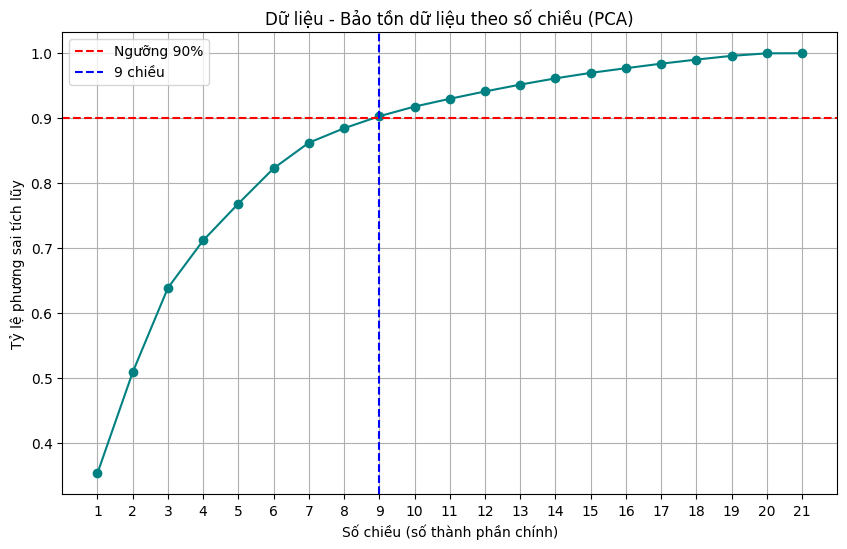

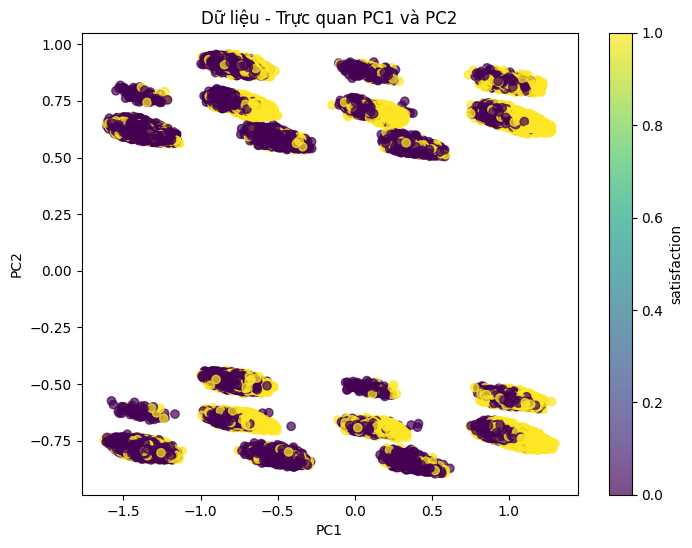

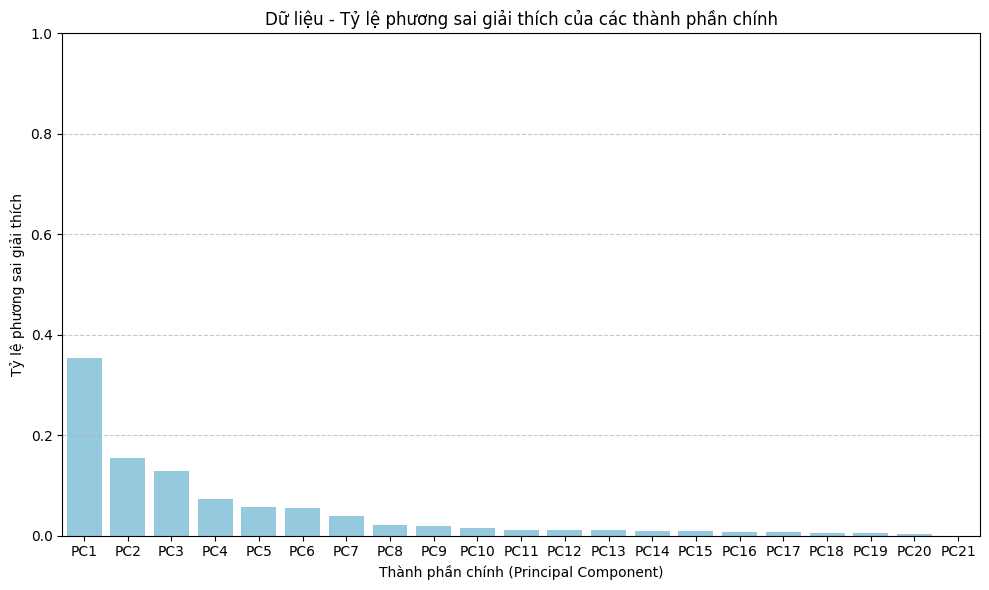

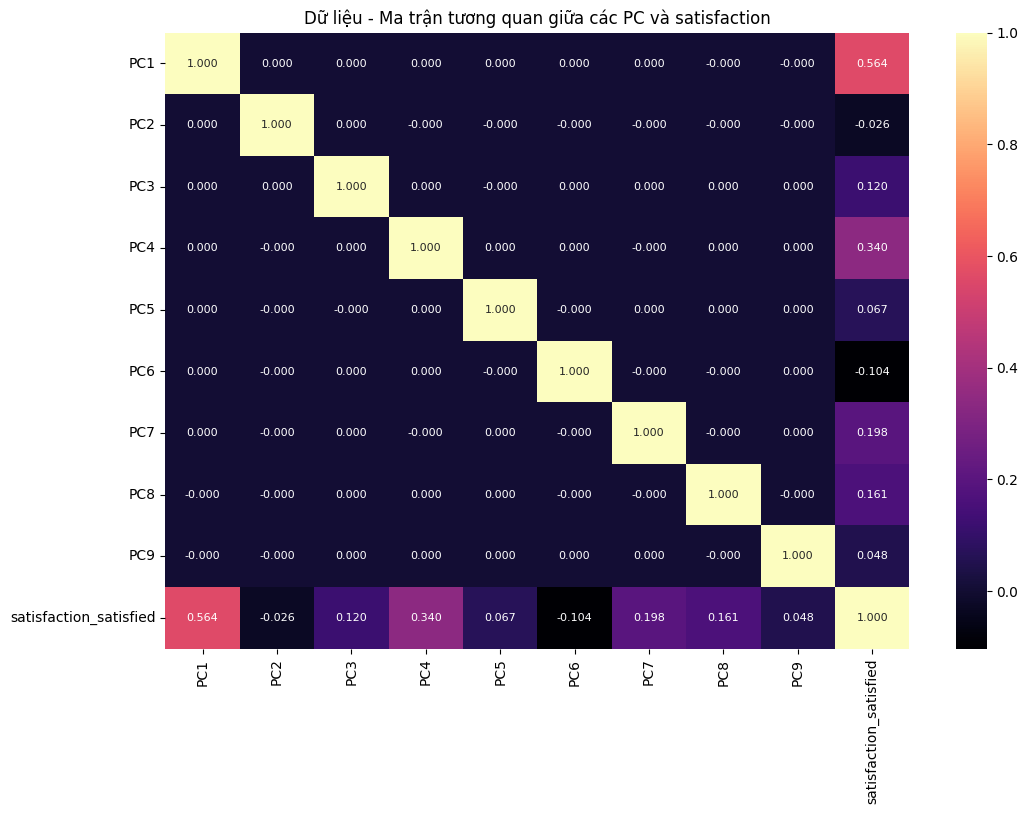

In [ ]:
nguong_pca = run_pca_analysis(X, Y, name = "Dữ liệu", n = 9)

Khởi tạo mô hình PCA với 9 thành phần chính—tương ứng 9 “trục” giàu phương sai nhất—rồi vừa huấn luyện vừa chiếu toàn bộ dữ liệu $X$ sang không gian mới đó.

`X_pca` là ma trận giảm còn 9 chiều, sẵn sàng đưa vào bước mô hình hoá tiếp theo.


In [ ]:
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components = 9)
X_pca = pca.fit_transform(X)

Nhận diện cấu trúc và mức độ tách cụm trong mặt phẳng hai PC đầu tiên.

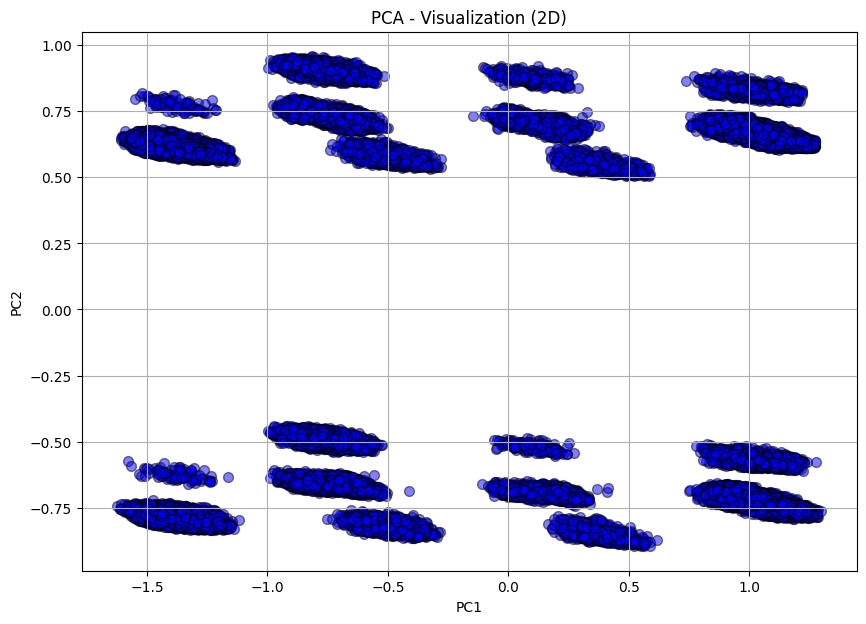

In [ ]:
# Visualize data with 2 principal components
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', edgecolor='k', s=50, alpha=0.5)
plt.title("PCA - Visualization (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.savefig('Clutering_PCA_2D.png')
plt.show()

Nhận diện cấu trúc và mức độ tách cụm trong mặt phẳng ba PC đầu tiên.

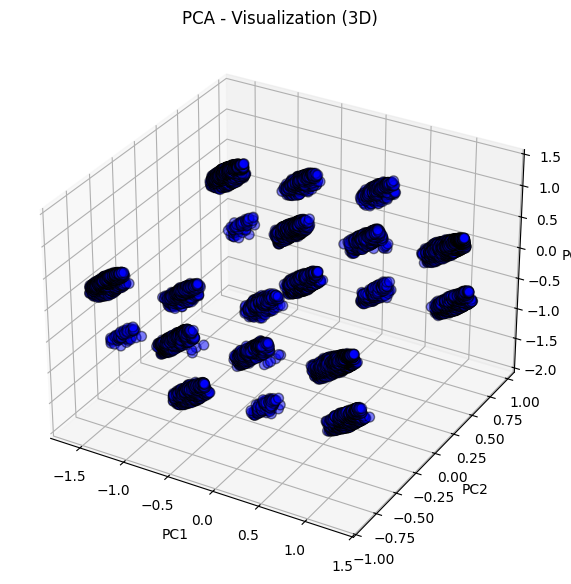

In [ ]:
# Visualize data with 3 principal components
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c='blue', edgecolor='k', s=50, alpha=0.5)
ax.set_title("PCA - Visualization (3D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.grid(True)
plt.savefig('Clutering_PCA_3D.png')
plt.show()

## Kmeans

Thử nghiệm thuật toán K-means với số cụm
𝑘 từ 2 đến 15 trên tập dữ liệu đã giảm chiều (`X_pca`).

 Với mỗi giá trị
𝑘
, chương trình huấn luyện mô hình, gán nhãn cho tất cả điểm dữ liệu, rồi tính ba chỉ số đánh giá chất lượng phân cụm: Silhouette (cao hơn nghĩa là cụm tách biệt rõ), Davies–Bouldin (thấp hơn càng tốt, biểu thị cụm ít chồng lấn) và Calinski–Harabasz (cao hơn cho thấy cụm chặt và khác biệt).

Kết quả của từng
𝑘 được lưu lại, in ra màn hình và vẽ trên ba biểu đồ đường để phân tích dễ dàng quan sát xu hướng và chọn giá trị
𝑘 tối ưu.

K=2, Silhouette Score: 0.33626, Davies-Bouldin Score: 1.30585, Calinski-Harabasz Score: 72757.64677
K=3, Silhouette Score: 0.32282, Davies-Bouldin Score: 1.40143, Calinski-Harabasz Score: 51318.10896
K=4, Silhouette Score: 0.28157, Davies-Bouldin Score: 1.51606, Calinski-Harabasz Score: 45794.33612
K=5, Silhouette Score: 0.28118, Davies-Bouldin Score: 1.41676, Calinski-Harabasz Score: 42085.35665
K=6, Silhouette Score: 0.31555, Davies-Bouldin Score: 1.28986, Calinski-Harabasz Score: 46059.04532
K=7, Silhouette Score: 0.32551, Davies-Bouldin Score: 1.30703, Calinski-Harabasz Score: 44789.51697
K=8, Silhouette Score: 0.28037, Davies-Bouldin Score: 1.66495, Calinski-Harabasz Score: 38972.06360
K=9, Silhouette Score: 0.29119, Davies-Bouldin Score: 1.52680, Calinski-Harabasz Score: 37710.63039
K=10, Silhouette Score: 0.29305, Davies-Bouldin Score: 1.44257, Calinski-Harabasz Score: 36743.65250
K=11, Silhouette Score: 0.29008, Davies-Bouldin Score: 1.36524, Calinski-Harabasz Score: 35936.9975

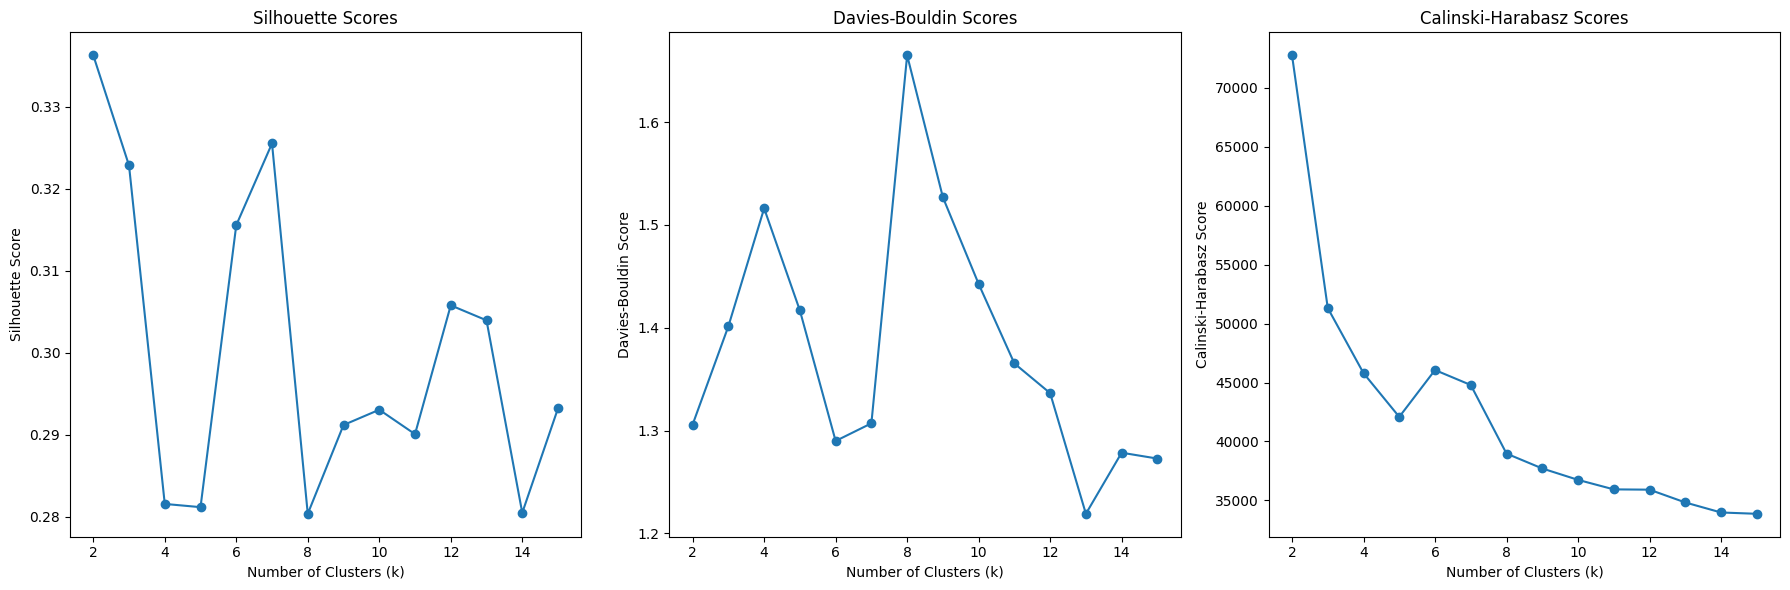

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Xác định phạm vi của k
k_range = range(2, 16)

# Khởi tạo các list để lưu kết quả
sil_scores = []
db_scores = []
ch_scores = []

# Thử các giá trị k từ 2 đến 15
for k in k_range:
    # KMeans model
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_pca)
    kmeans_labels = kmeans.fit_predict(X_pca)

    # Tính toán Silhouette score, Davies-Bouldin score và Calinski-Harabasz score
    sil_score = silhouette_score(X_pca, kmeans_labels)
    db_score = davies_bouldin_score(X_pca, kmeans_labels)
    ch_score = calinski_harabasz_score(X_pca, kmeans_labels)

    sil_scores.append(sil_score)
    db_scores.append(db_score)
    ch_scores.append(ch_score)

    print(f"K={k}, Silhouette Score: {sil_score:.5f}, Davies-Bouldin Score: {db_score:.5f}, Calinski-Harabasz Score: {ch_score:.5f}")

# Vẽ đồ thị Silhouette score, Davies-Bouldin score và Calinski-Harabasz score để tìm số cụm tối ưu
plt.figure(figsize=(18, 6))

# Vẽ Silhouette score
plt.subplot(1, 3, 1)
plt.plot(k_range, sil_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

# Vẽ Davies-Bouldin score
plt.subplot(1, 3, 2)
plt.plot(k_range, db_scores, marker='o')
plt.title('Davies-Bouldin Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Score')

# Vẽ Calinski-Harabasz score
plt.subplot(1, 3, 3)
plt.plot(k_range, ch_scores, marker='o')
plt.title('Calinski-Harabasz Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Calinski-Harabasz Score')

plt.tight_layout()
plt.show()

Chạy dữ liệu với K được chọn ở trên

In [ ]:
# KMeans model từ K đã chọn
kmeans = KMeans(n_clusters= 2, random_state=0)
kmeans.fit(X_pca)
kmeans_labels = kmeans.fit_predict(X_pca)

Tìm các tâm cụm của dữ liệu

In [ ]:
# labels of KMeans
centers = kmeans.cluster_centers_
print(centers)

[[-1.05352265  0.00959784 -0.06458288  0.05076754  0.00795179 -0.01563875
   0.01709539  0.00355138  0.00330673]
 [ 0.99095075 -0.0090278   0.06074711 -0.0477523  -0.00747951  0.01470992
  -0.01608005 -0.00334045 -0.00311033]]


Trực quan dữ liệu sau khi phân cụm KMeans trên 2 thành phần chính.

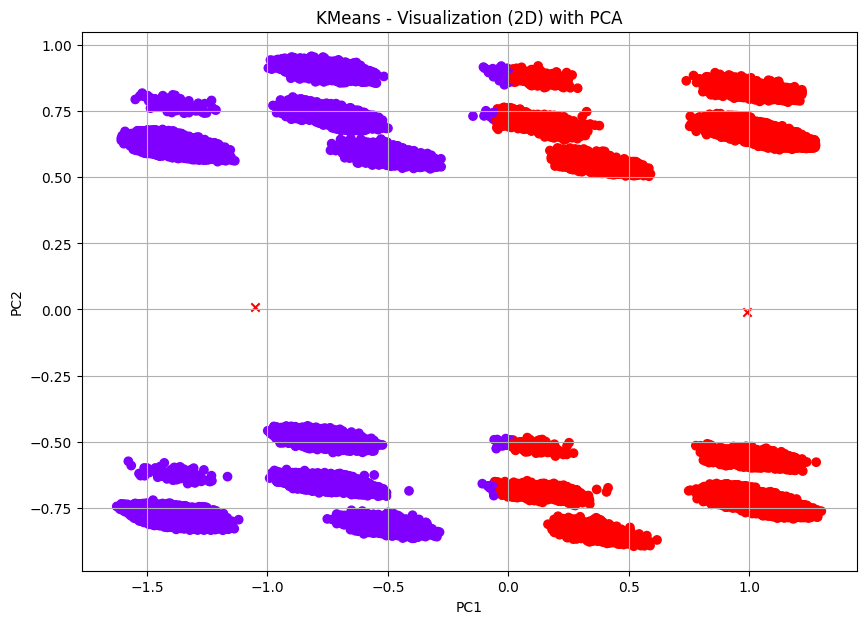

In [ ]:
# Visualize KMeans with 2 principal components
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='x')
plt.title("KMeans - Visualization (2D) with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.savefig('KMeans_2D_PCA.png')
plt.show()

Trực quan dữ liệu sau khi phân cụm KMeans trên 3 thành phần chính.

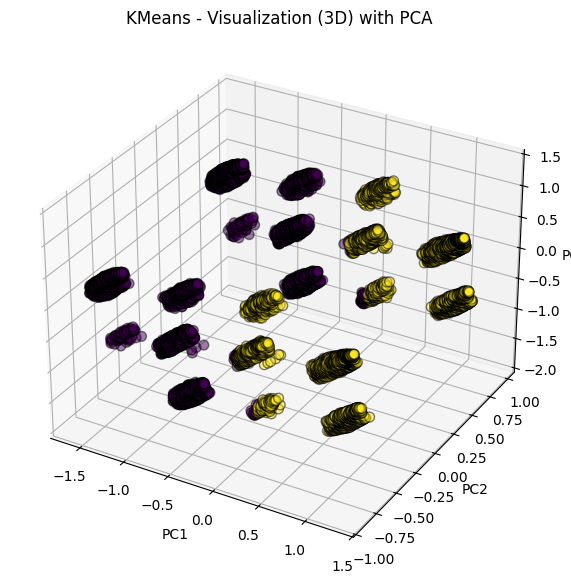

In [ ]:
# Visualize data with 3 principal components
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=kmeans_labels, edgecolor='k', s=50, alpha=0.5)
ax.set_title("KMeans - Visualization (3D) with PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.grid(True)
plt.savefig('KMeans_3D_PCA.png')
plt.show()

Tần suất phân bố mỗi cụm

Cụm 0 phân cụm khá tốt nhưng Cụm 0 bị 1/3 dữ liệu thật

In [ ]:
import pandas as pd

# Tạo DataFrame để dễ phân tích
df = pd.DataFrame({'Cluster': kmeans_labels, 'Output': Y.values.flatten()})

# Đếm tần suất nhãn trong mỗi cụm
cluster_counts = df.groupby(['Cluster', 'Output']).size().unstack(fill_value=0)
print(cluster_counts)

Output       0      1
Cluster              
0        51463  11315
1        21762  44947


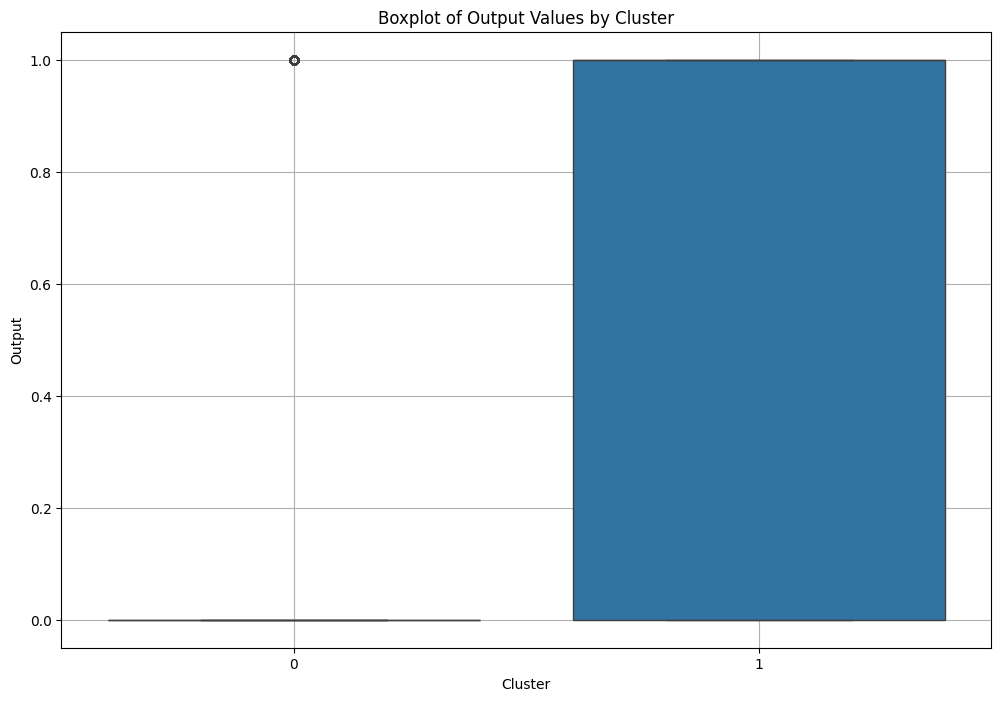

In [ ]:
# Biểu đồ hộp cho từng cụm
plt.figure(figsize=(12, 8))
sns.boxplot(x='Cluster', y='Output', data=df)
plt.title("Boxplot of Output Values by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Output")
plt.grid(True)
plt.savefig('Boxplot_Clustering.png')
plt.show()

## DBSCAN

In [ ]:
%pip install kneed

Tự động dò tìm bộ tham số tốt cho thuật toán DBSCAN trên tập dữ liệu đã giảm chiều ( `X_pca` ):

Quét min_samples từ 2 đến 20.

Với mỗi giá trị min_samples, tính đường k-distance rồi dùng phương pháp elbow (KneeLocator) để ước lượng ε (eps) tạm.

Chạy DBSCAN bằng cặp (eps, min_samples) vừa tìm, sau đó:

Đếm số cụm (bỏ qua kết quả sinh đúng 1 cụm).

Tính Silhouette score và Calinski–Harabasz score để đo độ “chất” của cụm.

Lưu lại hai thước đo này và vẽ biểu đồ so sánh chúng theo min_samples.

Chọn min_samples cho điểm Silhouette cao nhất ⇒ gọi là best_min.

Tính lại ε tối ưu cho best_min, vẽ đồ thị k-distance kèm vị trí “gấp khúc” (elbow).

In ra cặp thông số eps và min_samples tốt nhất.

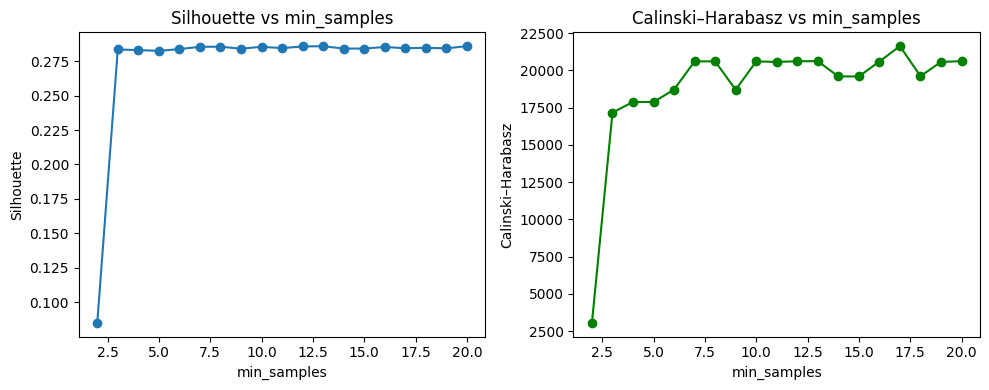

Optimal min_samples (by Silhouette): 20


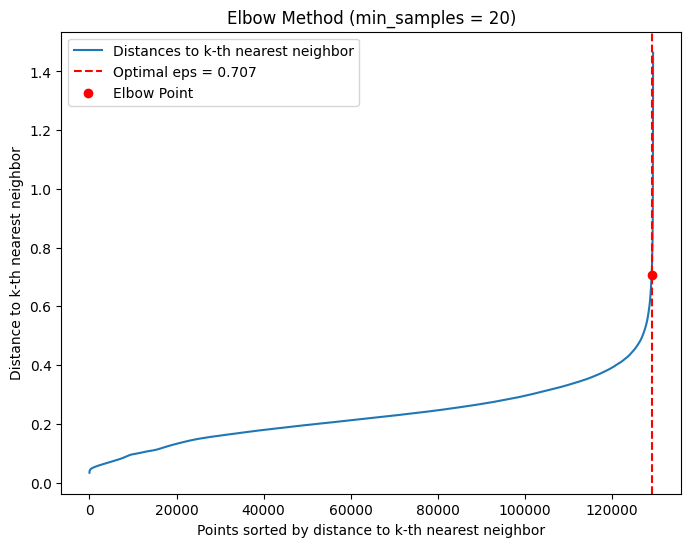


Optimal eps: 0.70667
Optimal min_samples: 20


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from kneed import KneeLocator

mins        = range(2, 21)
sil_scores  = []
ch_scores   = []

for ms in mins:
    # tìm ε tạm thời (elbow) cho mỗi min_samples
    nn   = NearestNeighbors(n_neighbors=ms).fit(X_pca)
    kdst = np.sort(nn.kneighbors(X_pca)[0][:, -1])        # k-distance
    knee = KneeLocator(range(len(kdst)), kdst,
                       curve="convex", direction="increasing")
    eps_tmp = kdst[knee.knee]

    # chạy DBSCAN tạm thời
    labels     = DBSCAN(eps=eps_tmp, min_samples=ms).fit_predict(X_pca)
    n_clusters = len(set(labels)) - (-1 in labels)

    # tính chỉ số nếu số cụm ≥ 2
    if n_clusters >= 2:
        sil = silhouette_score(X_pca, labels)
        ch  = calinski_harabasz_score(X_pca, labels)
    else:
        sil, ch = np.nan, np.nan           # bỏ qua nếu chỉ 1 cụm

    sil_scores.append(sil)
    ch_scores.append(ch)

# vẽ đường Silhouette & Calinski_harabasz
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(mins, sil_scores, marker='o')
ax[0].set_title("Silhouette vs min_samples")
ax[0].set_xlabel("min_samples"); ax[0].set_ylabel("Silhouette")

ax[1].plot(mins, ch_scores, marker='o', color='green')
ax[1].set_title("Calinski–Harabasz vs min_samples")
ax[1].set_xlabel("min_samples"); ax[1].set_ylabel("Calinski–Harabasz")

plt.tight_layout(); plt.show()

# chọn min_samples tốt nhất
valid        = np.isfinite(sil_scores)
best_idx     = np.nanargmax(np.array(sil_scores)[valid])
best_min     = np.array(mins)[valid][best_idx]
print(f"Optimal min_samples (by Silhouette): {best_min}")

# tìm ε cuối cùng cho best_min
nn   = NearestNeighbors(n_neighbors=best_min).fit(X_pca)
kdst = np.sort(nn.kneighbors(X_pca)[0][:, -1])
knee = KneeLocator(range(len(kdst)), kdst,
                   curve="convex", direction="increasing")
best_eps = kdst[knee.knee]

# vẽ đồ thị k-distance
plt.figure(figsize=(8, 6))
plt.plot(kdst, label="Distances to k-th nearest neighbor")
plt.axvline(knee.knee, color='r', ls='--',
            label=f"Optimal eps = {best_eps:.3f}")
plt.scatter(knee.knee, best_eps, color='red',
            label="Elbow Point", zorder=5)
plt.title(f"Elbow Method (min_samples = {best_min})")
plt.xlabel("Points sorted by distance to k-th nearest neighbor")
plt.ylabel("Distance to k-th nearest neighbor")
plt.legend(); plt.show()

print(f"\nOptimal eps: {best_eps:.5f}")
print(f"Optimal min_samples: {best_min}")

Chạy lại với 2 tham số eps và min_samples vừa tìm được ở trên

In [ ]:
# DBScan
dbscan = DBSCAN(eps=best_eps, min_samples=best_min)
dbscan.fit(X_pca)

DBSCAN(eps=np.float64(0.7066717297559125), min_samples=np.int64(20))

Cho biết mỗi điểm dữ liệu thuộc cụm nào hay là điểm nhiễu

In [ ]:
dbscan_labels = dbscan.fit_predict(X_pca)
dbscan_labels

array([0, 1, 2, ..., 4, 3, 4])

Giá trị độc lập của tất cả các nhãn điểm dữ liệu

In [ ]:
print(np.unique(dbscan_labels))

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


Trực quan hóa hình ảnh các cụm

Number of clusters: 20
Number of noise points: 49


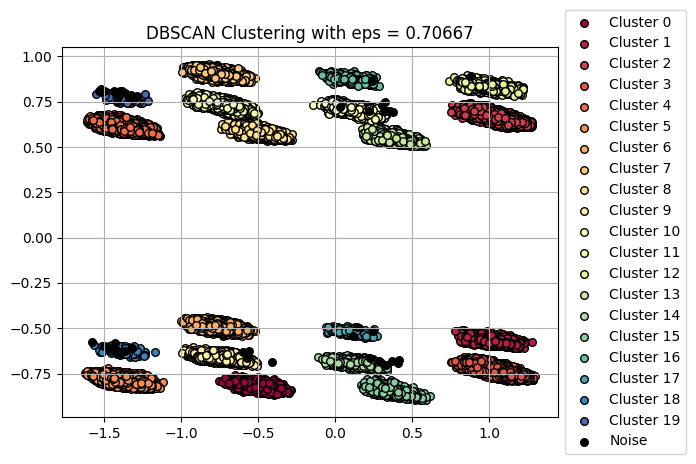

In [ ]:
# visualizing the clusters

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

# Trực quan hóa các cụm
unique_labels = set(dbscan_labels)

# Tạo danh sách màu sắc cho các cụm
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for label, color in zip(unique_labels, colors):
    if label == -1:
        # Điểm nhiễu (noise) được gắn nhãn là -1
        color = [0, 0, 0, 1]  # Màu đen cho noise

    # Lấy các điểm thuộc về cụm hiện tại
    cluster_points = (dbscan_labels == label)
    plt.scatter(
        X_pca[cluster_points, 0], X_pca[cluster_points, 1],
        c=[color], label=f"Cluster {label}" if label != -1 else "Noise",
        s=30, edgecolor='k'
    )

plt.title(f"DBSCAN Clustering with eps = {best_eps:.5f}")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.savefig('DBScan_Clustering_PCA.png')
plt.show()

Tần suất các điểm dữ liệu của các cụm

In [ ]:
import pandas as pd

# Tạo DataFrame để dễ phân tích
df = pd.DataFrame({'Cluster': dbscan_labels, 'Output': Y.values.flatten()})

# Đếm tần suất nhãn trong mỗi cụm
cluster_counts = df.groupby(['Cluster', 'Output']).size().unstack(fill_value=0)
print(cluster_counts)

Output       0      1
Cluster              
-1          35     14
 0        2016    196
 1        2664   1782
 2        5593  19515
 3        5453  19567
 4       14680   1676
 5       14703   1645
 6        5238    935
 7        6242    995
 8        2080    195
 9        3100   2834
 10       1047    912
 11       3100   2787
 12       2877   1873
 13       1161    152
 14       1088    933
 15       1178    161
 16        659     58
 17        176     11
 18         69     12
 19         66      9


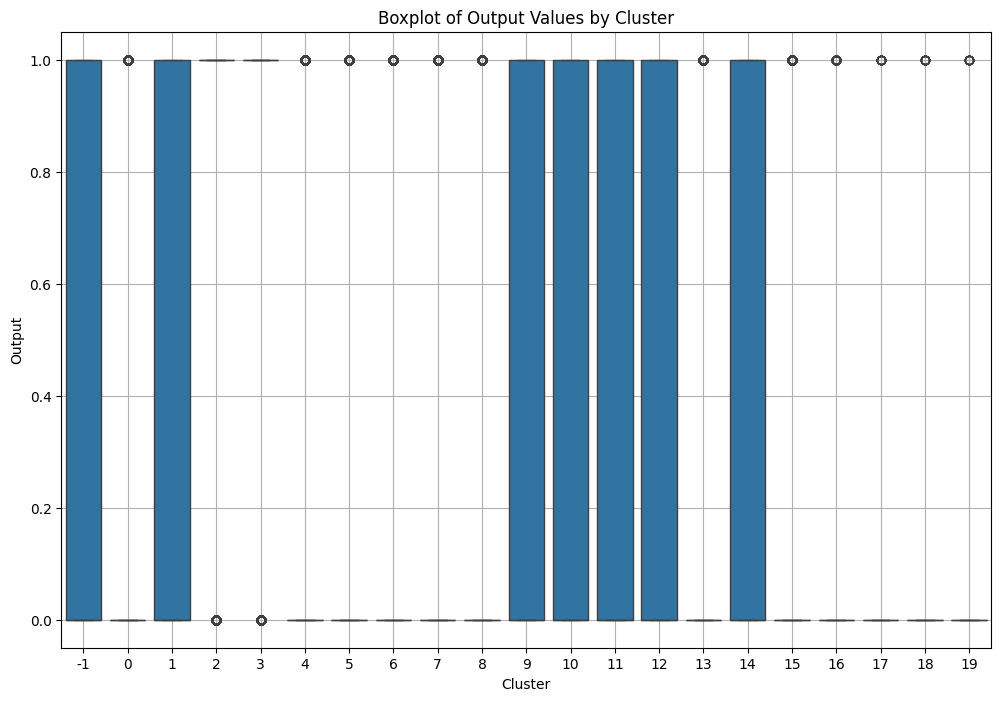

In [ ]:
# Biểu đồ hộp cho từng cụm
plt.figure(figsize=(12, 8))
sns.boxplot(x='Cluster', y='Output', data=df)
plt.title("Boxplot of Output Values by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Output")
plt.grid(True)
plt.savefig('Boxplot_Clustering.png')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Kiểm tra nếu DBSCAN có cụm hợp lệ
if len(set(dbscan_labels)) > 1:
    # Tính Silhouette Score
    sil_score = silhouette_score(X_pca, dbscan_labels)
    print(f"Silhouette Score: {sil_score:.5f}")

    # Tính Calinski-Harabasz Score
    ch_score = calinski_harabasz_score(X_pca, dbscan_labels)
    print(f"Calinski-Harabasz Score: {ch_score:.5f}")
else:
    print("DBSCAN không tạo được cụm hợp lệ.")

Silhouette Score: 0.28588
Calinski-Harabasz Score: 20613.68070


# Thuật toán phân cụm được giảm chiều bằng LDA

Giảm chiều dữ liệu gốc về dữ liệu `X_lda` về 1 chiều

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, Y)

Trực quan hình ảnh dữ liệu sau giảm chiều

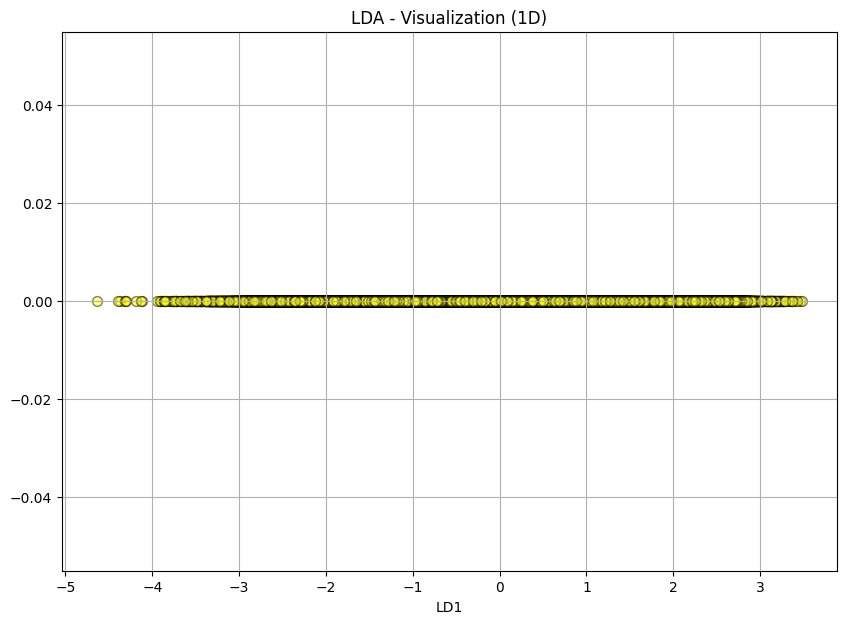

In [ ]:
# Visualize data with 1 principal component
plt.figure(figsize=(10, 7))
plt.scatter(X_lda[:, 0], [0] * len(X_lda), c='yellow', edgecolor='k', s=50, alpha=0.5) # Change here to plot against a constant y-value
plt.title("LDA - Visualization (1D)")
plt.xlabel("LD1")
plt.grid(True)
plt.savefig('Clutering_LDA_1D.png') # Change file name
plt.show()

Trực quan hóa dữ liệu trong không gian 3 chiều

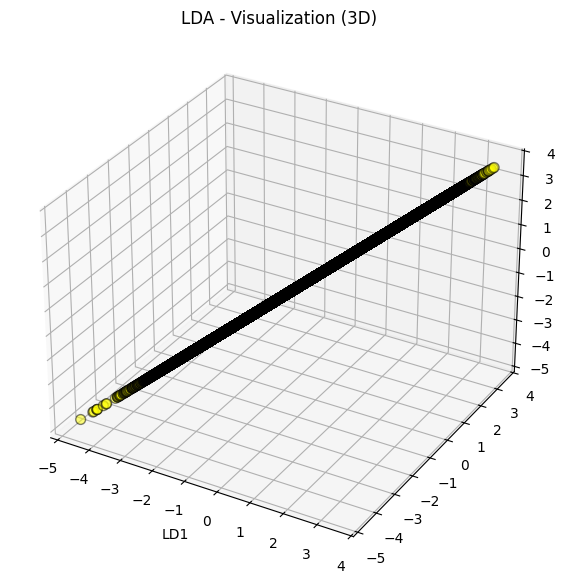

In [ ]:
# Visualize data with 1 principal component in 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Use X_lda[:, 0] for all three dimensions to represent the single component in 3D space
ax.scatter(X_lda[:, 0], X_lda[:, 0], X_lda[:, 0], c='yellow', edgecolor='k', s=50, alpha=0.5)

ax.set_title("LDA - Visualization (3D)")
ax.set_xlabel("LD1")
plt.grid(True)
plt.savefig('Clutering_LDA_3D.png')
plt.show()

## Kmeans

Thử nghiệm thuật toán K-means với số cụm
𝑘 từ 2 đến 15 trên tập dữ liệu đã giảm chiều (`X_lda`).

 Với mỗi giá trị
𝑘
, chương trình huấn luyện mô hình, gán nhãn cho tất cả điểm dữ liệu, rồi tính ba chỉ số đánh giá chất lượng phân cụm: Silhouette (cao hơn nghĩa là cụm tách biệt rõ), Davies–Bouldin (thấp hơn càng tốt, biểu thị cụm ít chồng lấn) và Calinski–Harabasz (cao hơn cho thấy cụm chặt và khác biệt).

Kết quả của từng
𝑘 được lưu lại, in ra màn hình và vẽ trên ba biểu đồ đường để phân tích dễ dàng quan sát xu hướng và chọn giá trị
𝑘 tối ưu.

K=2, Silhouette Score: 0.65697, Davies-Bouldin Score: 0.45160, Calinski-Harabasz Score: 432520.00816
K=3, Silhouette Score: 0.58305, Davies-Bouldin Score: 0.52969, Calinski-Harabasz Score: 505617.48020
K=4, Silhouette Score: 0.56017, Davies-Bouldin Score: 0.52934, Calinski-Harabasz Score: 597864.01018
K=5, Silhouette Score: 0.53862, Davies-Bouldin Score: 0.54196, Calinski-Harabasz Score: 671874.64621
K=6, Silhouette Score: 0.52947, Davies-Bouldin Score: 0.54090, Calinski-Harabasz Score: 758968.74102
K=7, Silhouette Score: 0.52722, Davies-Bouldin Score: 0.53456, Calinski-Harabasz Score: 843454.75014
K=8, Silhouette Score: 0.52360, Davies-Bouldin Score: 0.52992, Calinski-Harabasz Score: 937557.47008
K=9, Silhouette Score: 0.52186, Davies-Bouldin Score: 0.52736, Calinski-Harabasz Score: 1026873.40005
K=10, Silhouette Score: 0.51994, Davies-Bouldin Score: 0.52557, Calinski-Harabasz Score: 1078634.79361
K=11, Silhouette Score: 0.51912, Davies-Bouldin Score: 0.52425, Calinski-Harabasz Score:

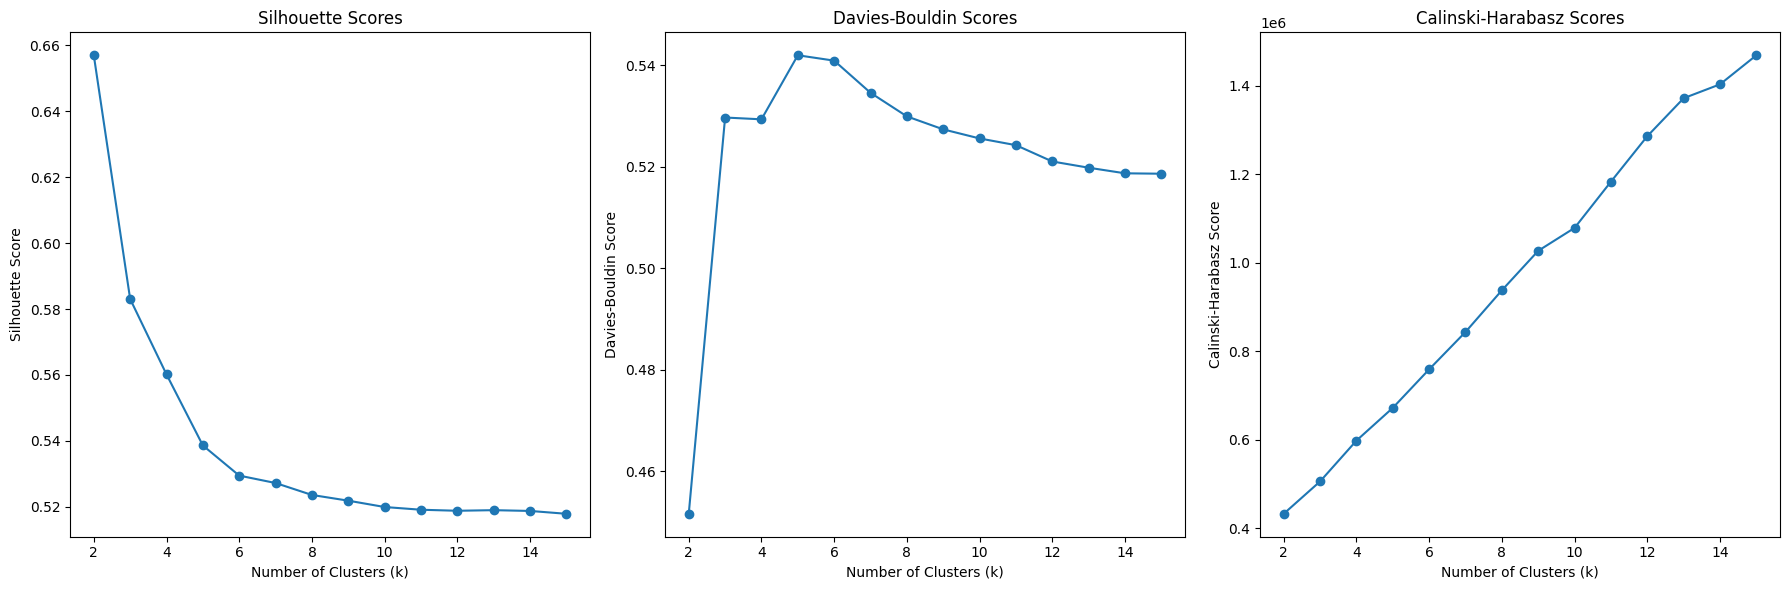

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Xác định phạm vi của k
k_range = range(2, 16)

# Khởi tạo các list để lưu kết quả
sil_scores = []
db_scores = []
ch_scores = []

# Thử các giá trị k từ 2 đến 15
for k in k_range:
    # KMeans model
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_lda)
    kmeans_labels = kmeans.fit_predict(X_lda)

    # Tính toán Silhouette score, Davies-Bouldin score và Calinski-Harabasz score
    sil_score = silhouette_score(X_lda, kmeans_labels)
    db_score = davies_bouldin_score(X_lda, kmeans_labels)
    ch_score = calinski_harabasz_score(X_lda, kmeans_labels)

    sil_scores.append(sil_score)
    db_scores.append(db_score)
    ch_scores.append(ch_score)

    print(f"K={k}, Silhouette Score: {sil_score:.5f}, Davies-Bouldin Score: {db_score:.5f}, Calinski-Harabasz Score: {ch_score:.5f}")

# Vẽ đồ thị Silhouette score, Davies-Bouldin score và Calinski-Harabasz score để tìm số cụm tối ưu
plt.figure(figsize=(18, 6))

# Vẽ Silhouette score
plt.subplot(1, 3, 1)
plt.plot(k_range, sil_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

# Vẽ Davies-Bouldin score
plt.subplot(1, 3, 2)
plt.plot(k_range, db_scores, marker='o')
plt.title('Davies-Bouldin Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Score')

# Vẽ Calinski-Harabasz score
plt.subplot(1, 3, 3)
plt.plot(k_range, ch_scores, marker='o')
plt.title('Calinski-Harabasz Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Calinski-Harabasz Score')

plt.tight_layout()
plt.show()

Chạy dữ liệu với K được chọn ở trên

In [ ]:
# KMeans model từ K đã chọn
kmeans = KMeans(n_clusters= 2, random_state=0)
kmeans.fit(X_lda)
kmeans_labels = kmeans.fit_predict(X_lda)

Tìm các tâm cụm của dữ liệu

In [ ]:
# labels of KMeans
centers = kmeans.cluster_centers_
print(centers)

[[-1.14581561]
 [ 1.49231074]]


Trực quan dữ liệu sau khi phân cụm KMeans trên 2 thành phần chính.

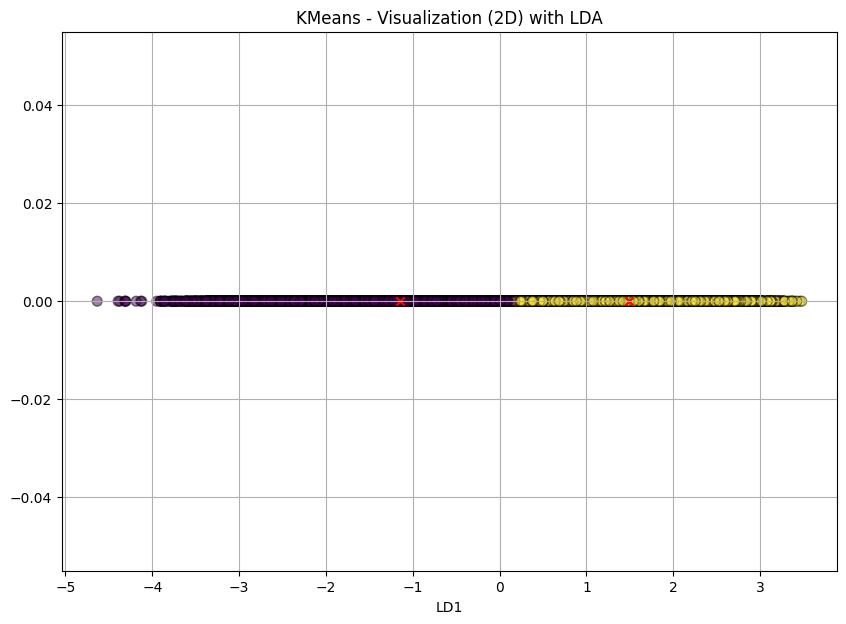

In [ ]:
# Visualize KMeans with 1 principal components
plt.figure(figsize=(10, 7))
plt.scatter(X_lda[:, 0], [0] * len(X_lda), c=kmeans_labels, edgecolor='k', s=50, alpha=0.5)
# The cluster centers only have one dimension, so we plot them against a constant y-value
plt.scatter(kmeans.cluster_centers_[:, 0], [0] * len(kmeans.cluster_centers_), c='red', marker='x')
plt.title("KMeans - Visualization (2D) with LDA")
plt.xlabel("LD1")
plt.grid(True)
plt.savefig('KMeans_2D_LDA.png')
plt.show()

Trực quan dữ liệu sau khi phân cụm KMeans trên 3 thành phần chính.

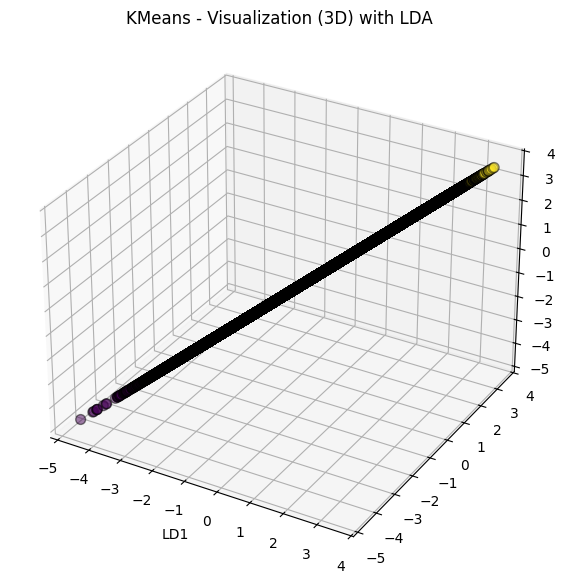

In [ ]:
# Visualize data with 1 principal components
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_lda[:, 0], X_lda[:, 0], X_lda[:, 0], c=kmeans_labels, edgecolor='k', s=50, alpha=0.5)
ax.set_title("KMeans - Visualization (3D) with LDA")
ax.set_xlabel("LD1")
plt.grid(True)
plt.savefig('KMeans_3D_LDA.png')
plt.show()

Tần suất phân bố mỗi cụm

In [ ]:
import pandas as pd

# Tạo DataFrame để dễ phân tích
df = pd.DataFrame({'Cluster': kmeans_labels, 'Output': Y.values.flatten()})

# Đếm tần suất nhãn trong mỗi cụm
cluster_counts = df.groupby(['Cluster', 'Output']).size().unstack(fill_value=0)
print(cluster_counts)

Output       0      1
Cluster              
0        64709   8632
1         8516  47630


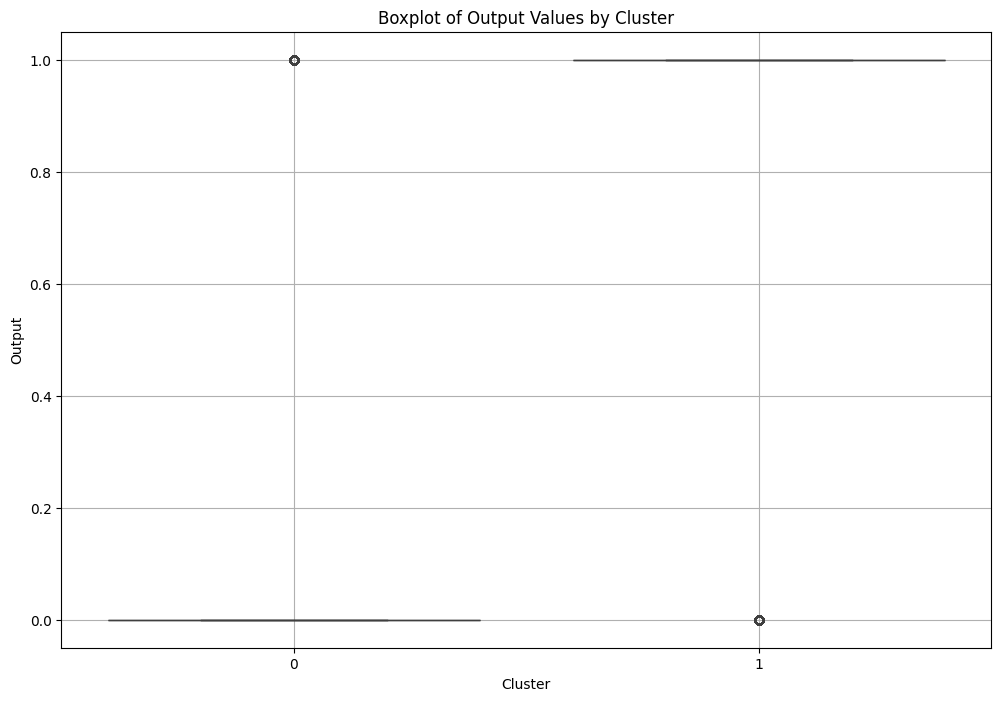

In [ ]:
# Biểu đồ hộp cho từng cụm
plt.figure(figsize=(12, 8))
sns.boxplot(x='Cluster', y='Output', data=df)
plt.title("Boxplot of Output Values by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Output")
plt.grid(True)
plt.savefig('Boxplot_Clustering.png')
plt.show()

## DBSCAN

Tự động dò tìm bộ tham số tốt cho thuật toán DBSCAN trên tập dữ liệu đã giảm chiều ( `X_lda` ):

Quét min_samples từ 2 đến 20.

Với mỗi giá trị min_samples, tính đường k-distance rồi dùng phương pháp elbow (KneeLocator) để ước lượng ε (eps) tạm.

Chạy DBSCAN bằng cặp (eps, min_samples) vừa tìm, sau đó:

Đếm số cụm (bỏ qua kết quả sinh đúng 1 cụm).

Tính Silhouette score và Calinski–Harabasz score để đo độ “chất” của cụm.

Lưu lại hai thước đo này và vẽ biểu đồ so sánh chúng theo min_samples.

Chọn min_samples cho điểm Silhouette cao nhất ⇒ gọi là best_min.

Tính lại ε tối ưu cho best_min, vẽ đồ thị k-distance kèm vị trí “gấp khúc” (elbow).

In ra cặp thông số eps và min_samples tốt nhất.

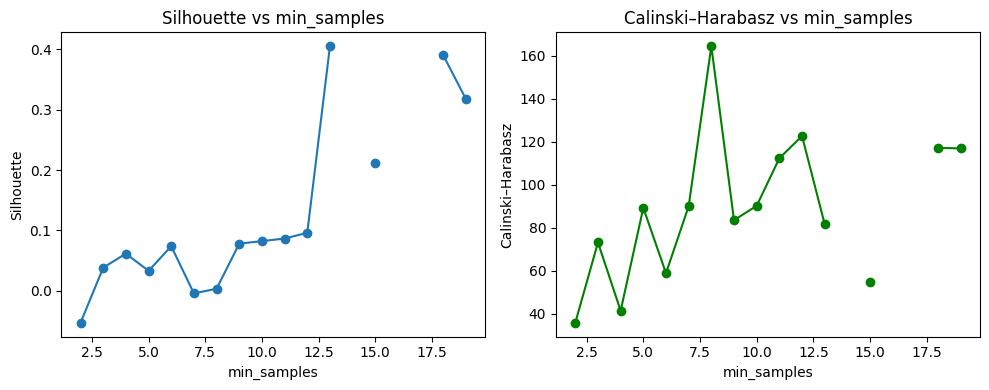

Optimal min_samples (by Silhouette): 13


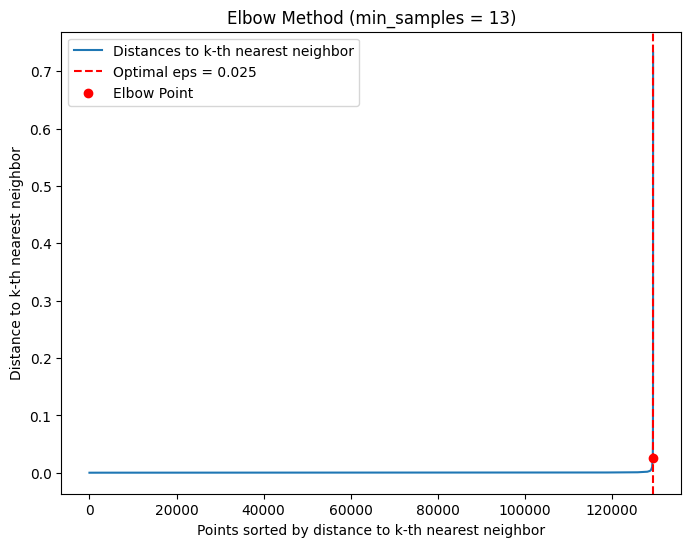


Optimal eps       : 0.02515
Optimal min_samples: 13


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from kneed import KneeLocator

mins        = range(2, 21)
sil_scores  = []
ch_scores   = []

for ms in mins:
    # tìm ε tạm thời (elbow) cho mỗi min_samples
    nn   = NearestNeighbors(n_neighbors=ms).fit(X_lda)
    kdst = np.sort(nn.kneighbors(X_lda)[0][:, -1])        # k-distance
    knee = KneeLocator(range(len(kdst)), kdst,
                       curve="convex", direction="increasing")
    eps_tmp = kdst[knee.knee]

    # chạy DBSCAN tạm thời
    labels     = DBSCAN(eps=eps_tmp, min_samples=ms).fit_predict(X_lda)
    n_clusters = len(set(labels)) - (-1 in labels)

    # tính chỉ số nếu số cụm ≥ 2
    if n_clusters >= 2:
        sil = silhouette_score(X_lda, labels)
        ch  = calinski_harabasz_score(X_lda, labels)
    else:
        sil, ch = np.nan, np.nan           # bỏ qua nếu chỉ 1 cụm

    sil_scores.append(sil)
    ch_scores.append(ch)

# vẽ đường Silhouette & Calinski_harabasz
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(mins, sil_scores, marker='o')
ax[0].set_title("Silhouette vs min_samples")
ax[0].set_xlabel("min_samples"); ax[0].set_ylabel("Silhouette")

ax[1].plot(mins, ch_scores, marker='o', color='green')
ax[1].set_title("Calinski–Harabasz vs min_samples")
ax[1].set_xlabel("min_samples"); ax[1].set_ylabel("Calinski–Harabasz")

plt.tight_layout(); plt.show()

# chọn min_samples tốt nhất
valid        = np.isfinite(sil_scores)
best_idx     = np.nanargmax(np.array(sil_scores)[valid])
best_min     = np.array(mins)[valid][best_idx]
print(f"Optimal min_samples (by Silhouette): {best_min}")

# tìm ε cuối cùng cho best_min
nn   = NearestNeighbors(n_neighbors=best_min).fit(X_lda)
kdst = np.sort(nn.kneighbors(X_lda)[0][:, -1])
knee = KneeLocator(range(len(kdst)), kdst,
                   curve="convex", direction="increasing")
best_eps = kdst[knee.knee]

# vẽ đồ thị k-distance
plt.figure(figsize=(8, 6))
plt.plot(kdst, label="Distances to k-th nearest neighbor")
plt.axvline(knee.knee, color='r', ls='--',
            label=f"Optimal eps = {best_eps:.3f}")
plt.scatter(knee.knee, best_eps, color='red',
            label="Elbow Point", zorder=5)
plt.title(f"Elbow Method (min_samples = {best_min})")
plt.xlabel("Points sorted by distance to k-th nearest neighbor")
plt.ylabel("Distance to k-th nearest neighbor")
plt.legend(); plt.show()

print(f"\nOptimal eps: {best_eps:.5f}")
print(f"Optimal min_samples: {best_min}")

Chạy lại với 2 tham số eps và min_samples đã chọn ở trên

In [ ]:
# DBScan
dbscan = DBSCAN(eps=best_eps, min_samples=best_min)
dbscan.fit(X_lda)

DBSCAN(eps=np.float64(0.02514689997799424), min_samples=np.int64(13))

Nhãn của các điểm dữ liệu

In [ ]:
dbscan_labels = dbscan.fit_predict(X_lda)
dbscan_labels

array([0, 0, 0, ..., 0, 0, 0])

Giá trị độc lập của tất cả các nhãn

In [ ]:
print(np.unique(dbscan_labels))

[-1  0  1]


Trực quan hình ảnh đã phân cụm DBSCAN

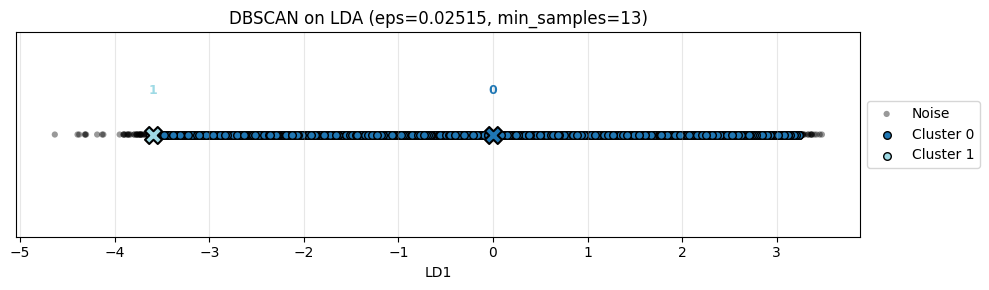

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cluster_labels = [l for l in unique_labels if l != -1]   # chỉ còn cụm thật
n_clusters     = len(cluster_labels)

# colormap liên tục và chuẩn hoá chỉ số
cmap = plt.colormaps.get_cmap('tab20')

plt.figure(figsize=(10, 3))

# vẽ noise trước (nếu có)
mask_noise = (dbscan_labels == -1)
if mask_noise.any():
    plt.scatter(X_lda[mask_noise, 0], np.zeros(mask_noise.sum()),
                c='k', s=20, alpha=.4, label='Noise', edgecolors='none')

# vẽ từng cụm
for idx, label in enumerate(cluster_labels):          # idx = 0..n_clusters-1
    mask  = (dbscan_labels == label)
    color = cmap(idx / max(1, n_clusters-1))          # chuẩn hoá 0→1

    plt.scatter(X_lda[mask, 0], np.zeros(mask.sum()),
                c=[color], s=30, edgecolor='k', label=f'Cluster {label}')

    # centroid
    cx = X_lda[mask, 0].mean()
    plt.scatter(cx, 0, marker='X', s=150, c=[color],
                edgecolor='k', lw=1.5, zorder=5)
    plt.text(cx, 0.02, str(label), ha='center', va='bottom',
             fontsize=9, weight='bold', color=color)

plt.title(f"DBSCAN on LDA (eps={best_eps:.5f}, min_samples={best_min})")
plt.yticks([]); plt.xlabel('LD1'); plt.grid(alpha=.3, axis='x')
plt.legend(loc='center left', bbox_to_anchor=(1, .5))
plt.tight_layout(); plt.show()

Tần suất các điểm dữ liệu của các cụm

In [ ]:
import pandas as pd

# Tạo DataFrame để dễ phân tích
df = pd.DataFrame({'Cluster': dbscan_labels, 'Output': Y.values.flatten()})

# Đếm tần suất nhãn trong mỗi cụm
cluster_counts = df.groupby(['Cluster', 'Output']).size().unstack(fill_value=0)
print(cluster_counts)

Output       0      1
Cluster              
-1          34     33
 0       73183  56224
 1           8      5


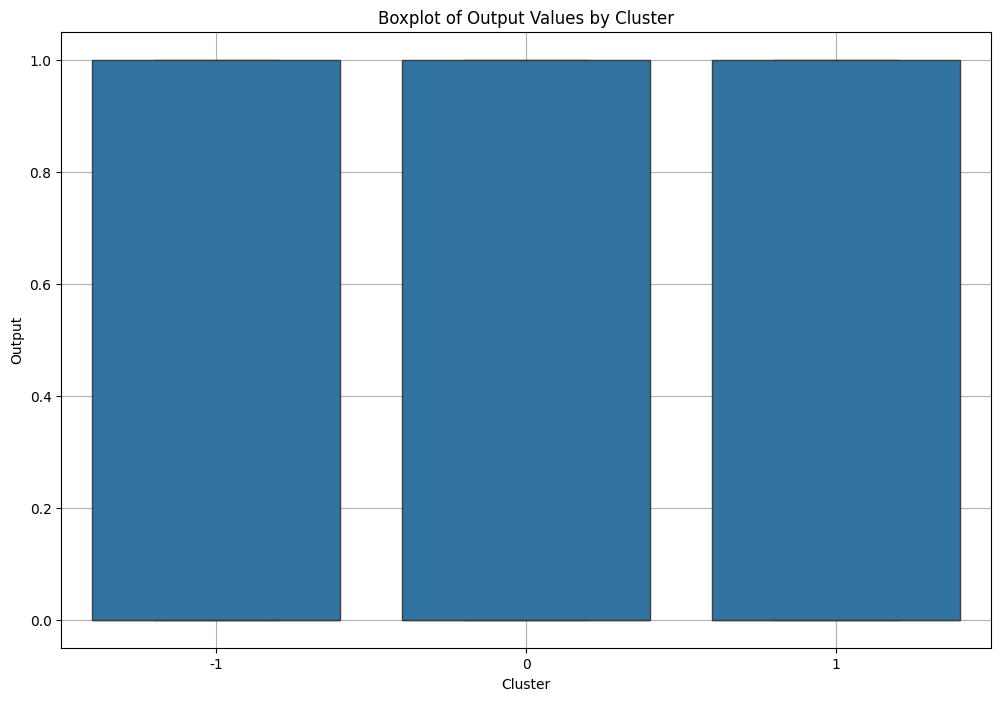

In [ ]:
# Biểu đồ hộp cho từng cụm
plt.figure(figsize=(12, 8))
sns.boxplot(x='Cluster', y='Output', data=df)
plt.title("Boxplot of Output Values by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Output")
plt.grid(True)
plt.savefig('Boxplot_Clustering.png')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Kiểm tra nếu DBSCAN có cụm hợp lệ
if len(set(dbscan_labels)) > 1:
    # Tính Silhouette Score
    sil_score = silhouette_score(X_lda, dbscan_labels)
    print(f"Silhouette Score: {sil_score:.5f}")

    # Tính Calinski-Harabasz Score
    ch_score = calinski_harabasz_score(X_lda, dbscan_labels)
    print(f"Calinski-Harabasz Score: {ch_score:.5f}")
else:
    print("DBSCAN không tạo được cụm hợp lệ.")

Silhouette Score: 0.40533
Calinski-Harabasz Score: 81.74065
